# **SCENARIO 1 – Bagging Classifier (Diabetes Dataset)**

   Glucose   BMI  Age  BloodPressure  Insulin  Outcome
0      182  21.1   45             99      100        1
1      131  35.6   67             92      199        1
2      172  19.6   68             68      234        1
3       94  39.7   21            102       83        0
4      186  35.0   20            113       61        1
Shape: (120, 6)
Decision Tree Accuracy : 1.0000
Bagging Accuracy       : 1.0000


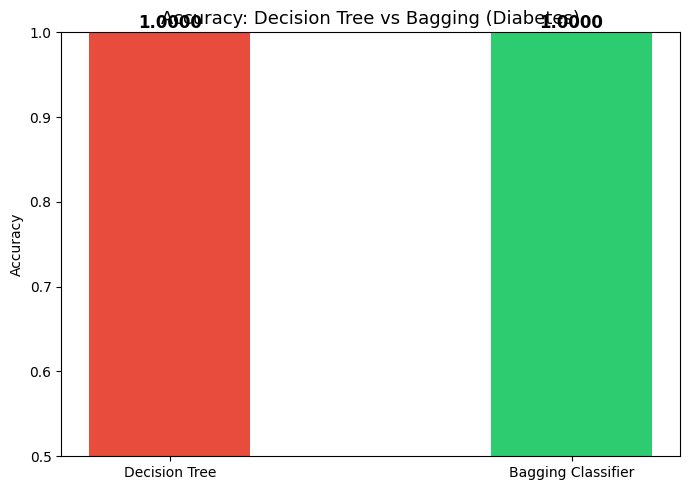

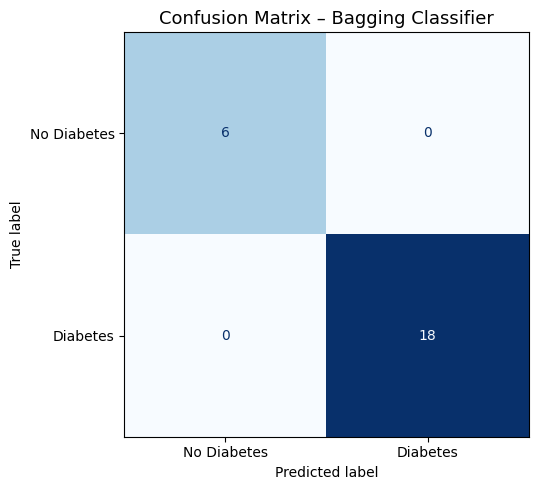

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Load Dataset
df = pd.read_csv("diabetes_bagging.csv")
print(df.head())
print("Shape:", df.shape)

# 2. Features & Target
X = df[["Glucose", "BMI", "Age", "BloodPressure", "Insulin"]]
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))
print(f"Decision Tree Accuracy : {dt_acc:.4f}")

# 4. Apply BaggingClassifier
bag = BaggingClassifier(estimator=DecisionTreeClassifier(),
                        n_estimators=50, random_state=42)
bag.fit(X_train, y_train)
bag_pred = bag.predict(X_test)
bag_acc  = accuracy_score(y_test, bag_pred)
print(f"Bagging Accuracy       : {bag_acc:.4f}")

# 5. Visualization 1 – Accuracy Comparison Bar Graph
models     = ["Decision Tree", "Bagging Classifier"]
accuracies = [dt_acc, bag_acc]

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies, color=["#e74c3c", "#2ecc71"], width=0.4)
plt.ylim(0.5, 1.0)
plt.title("Accuracy: Decision Tree vs Bagging (Diabetes)", fontsize=13)
plt.ylabel("Accuracy")
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f"{acc:.4f}", ha="center", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("s1_accuracy_comparison.png", dpi=150)
plt.show()

# 6. Visualization 2 – Confusion Matrix
cm   = confusion_matrix(y_test, bag_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Diabetes", "Diabetes"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix – Bagging Classifier", fontsize=13)
plt.tight_layout()
plt.savefig("s1_confusion_matrix.png", dpi=150)
plt.show()

# **Scenario 2 – Boosting: AdaBoost & Gradient Boosting (Customer Churn)**

   Tenure  MonthlyCharges    ContractType InternetService  Churn
0      65          105.22        Two year             NaN      0
1      17           75.19  Month-to-month             NaN      0
2      71           76.09        Two year     Fiber optic      0
3      45          107.67        Two year     Fiber optic      0
4       4           60.35        Two year             NaN      0
AdaBoost Accuracy       : 1.0000
Gradient Boost Accuracy : 1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


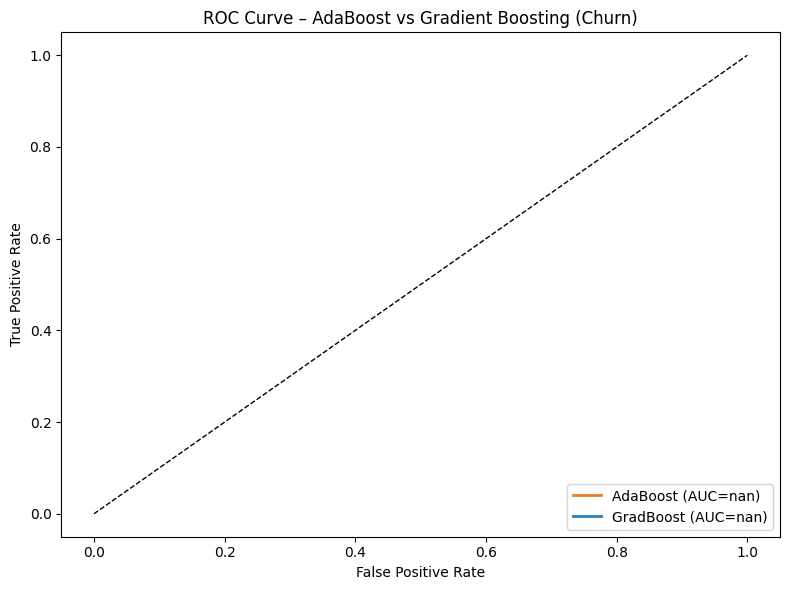

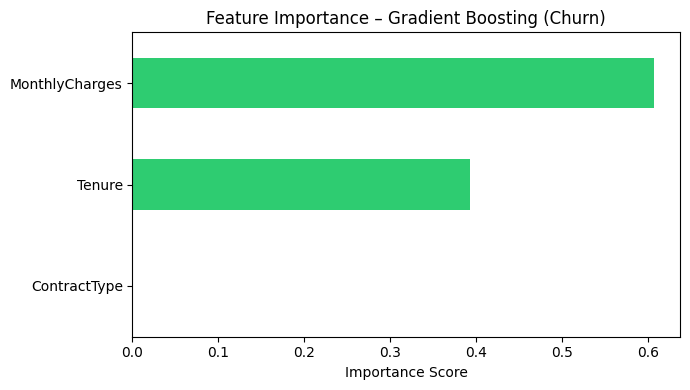

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_curve, auc

# 1. Load Dataset
df = pd.read_csv("churn_boosting.csv")
print(df.head())

# 2. Encode Categorical Columns (ContractType, InternetService)
le = LabelEncoder()
df["ContractType"]    = le.fit_transform(df["ContractType"])
df["InternetService"] = le.fit_transform(df["InternetService"])

# 3. Features & Target
X = df[["Tenure", "MonthlyCharges", "ContractType"]]
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Train AdaBoost
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
ada_prob = ada.predict_proba(X_test)[:, 1]
ada_acc  = accuracy_score(y_test, ada.predict(X_test))
print(f"AdaBoost Accuracy       : {ada_acc:.4f}")

# 5. Train Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_prob = gb.predict_proba(X_test)[:, 1]
gb_acc  = accuracy_score(y_test, gb.predict(X_test))
print(f"Gradient Boost Accuracy : {gb_acc:.4f}")

# 6. Visualization 1 – ROC Curve
fpr_a, tpr_a, _ = roc_curve(y_test, ada_prob)
fpr_g, tpr_g, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr_a, tpr_a, label=f"AdaBoost (AUC={auc(fpr_a,tpr_a):.3f})",
         color="#e67e22", lw=2)
plt.plot(fpr_g, tpr_g, label=f"GradBoost (AUC={auc(fpr_g,tpr_g):.3f})",
         color="#2980b9", lw=2)
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – AdaBoost vs Gradient Boosting (Churn)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("s2_roc_curve.png", dpi=150)
plt.show()

# 7. Visualization 2 – Feature Importance (Gradient Boosting)
feat_imp = pd.Series(gb.feature_importances_,
                     index=["Tenure", "MonthlyCharges", "ContractType"]).sort_values()

plt.figure(figsize=(7, 4))
feat_imp.plot(kind="barh", color="#2ecc71")
plt.title("Feature Importance – Gradient Boosting (Churn)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("s2_feature_importance.png", dpi=150)
plt.show()

# **Scenario 3 – Random Forest (Adult Income Prediction)**

   Age  EducationYears  HoursPerWeek  Experience  Income
0   37              12            44          12       0
1   46              19            58          33       1
2   53              10            54          24       0
3   46              11            22           6       0
4   36              17            56           3       1
Shape: (120, 5)
Random Forest Accuracy (100 trees): 1.0000


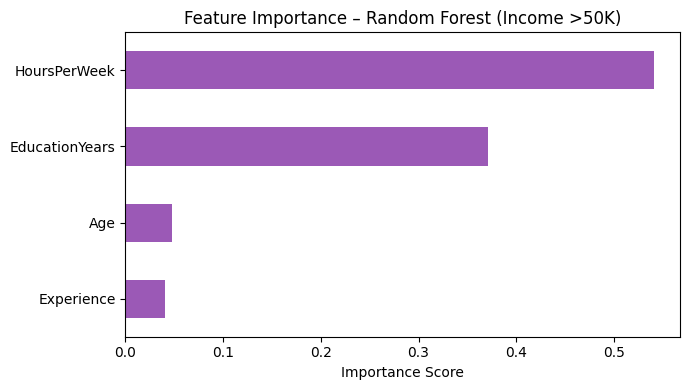

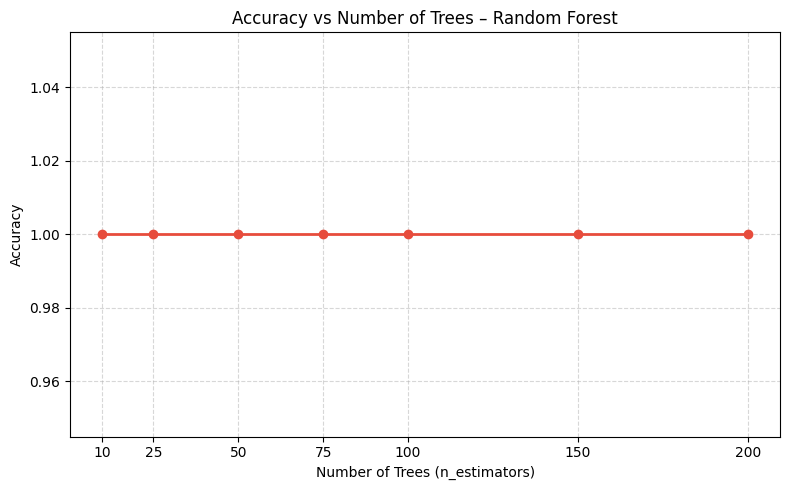

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load Dataset
df = pd.read_csv("income_random_forest.csv")
print(df.head())
print("Shape:", df.shape)

# 2. Features & Target
features = ["Age", "EducationYears", "HoursPerWeek", "Experience"]
X = df[features]
y = df["Income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Train Random Forest (100 trees)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest Accuracy (100 trees): {rf_acc:.4f}")

# 4. Tune Number of Trees
tree_range = [10, 25, 50, 75, 100, 150, 200]
acc_list   = []
for n in tree_range:
    clf = RandomForestClassifier(n_estimators=n, random_state=42)
    clf.fit(X_train, y_train)
    acc_list.append(accuracy_score(y_test, clf.predict(X_test)))

# 5. Visualization 1 – Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values()

plt.figure(figsize=(7, 4))
feat_imp.plot(kind="barh", color="#9b59b6")
plt.title("Feature Importance – Random Forest (Income >50K)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("s3_feature_importance.png", dpi=150)
plt.show()

# 6. Visualization 2 – Accuracy vs Number of Trees
plt.figure(figsize=(8, 5))
plt.plot(tree_range, acc_list, marker="o", color="#e74c3c", linewidth=2)
plt.title("Accuracy vs Number of Trees – Random Forest")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.xticks(tree_range)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("s3_accuracy_vs_trees.png", dpi=150)
plt.show()

# **Scenario 4 – Stacking (Heart Disease Prediction)**

   Age  Cholesterol  MaxHeartRate  RestingBP  HeartDisease
0   57          212           189        118             0
1   44          266           155        146             1
2   59          279           168        128             1
3   66          237           123        145             1
4   58          221           125        132             0
Shape: (120, 5)
Logistic Regression Accuracy : 0.8333
SVM Accuracy                 : 0.8750
Decision Tree Accuracy       : 0.9583
Stacking Classifier Accuracy : 0.9583


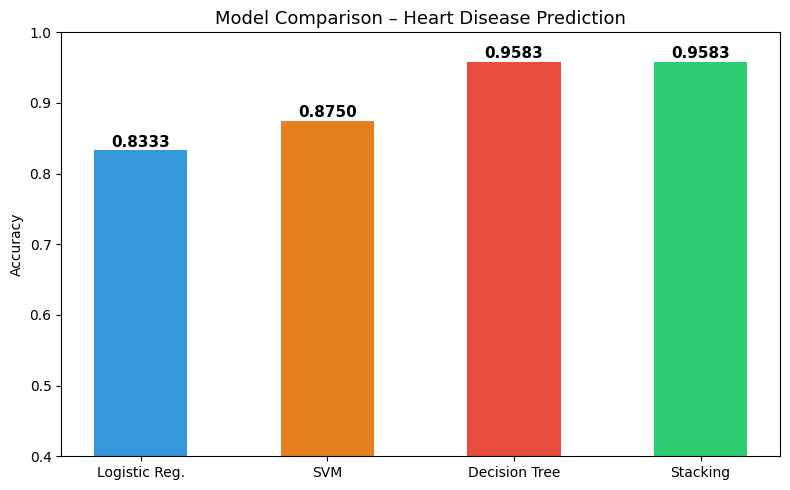

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. Load Dataset
df = pd.read_csv("heart_stacking.csv")
print(df.head())
print("Shape:", df.shape)

# 2. Features & Target
X = df[["Cholesterol", "MaxHeartRate", "Age", "RestingBP"]]
y = df["HeartDisease"]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 3. Train Individual Base Models
lr  = LogisticRegression(max_iter=1000, random_state=42)
svm = SVC(probability=True, random_state=42)
dt  = DecisionTreeClassifier(random_state=42)

lr.fit(X_train,  y_train); lr_acc  = accuracy_score(y_test, lr.predict(X_test))
svm.fit(X_train, y_train); svm_acc = accuracy_score(y_test, svm.predict(X_test))
dt.fit(X_train,  y_train); dt_acc  = accuracy_score(y_test, dt.predict(X_test))

print(f"Logistic Regression Accuracy : {lr_acc:.4f}")
print(f"SVM Accuracy                 : {svm_acc:.4f}")
print(f"Decision Tree Accuracy       : {dt_acc:.4f}")

# 4. Stacking Classifier
estimators = [
    ("lr",  LogisticRegression(max_iter=1000, random_state=42)),
    ("svm", SVC(probability=True, random_state=42)),
    ("dt",  DecisionTreeClassifier(random_state=42))
]
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)
stack.fit(X_train, y_train)
stack_acc = accuracy_score(y_test, stack.predict(X_test))
print(f"Stacking Classifier Accuracy : {stack_acc:.4f}")

# 5. Visualization – Model Comparison Bar Chart
models     = ["Logistic Reg.", "SVM", "Decision Tree", "Stacking"]
accuracies = [lr_acc, svm_acc, dt_acc, stack_acc]
colors     = ["#3498db", "#e67e22", "#e74c3c", "#2ecc71"]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, width=0.5)
plt.ylim(0.4, 1.0)
plt.title("Model Comparison – Heart Disease Prediction", fontsize=13)
plt.ylabel("Accuracy")
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f"{acc:.4f}", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("s4_model_comparison.png", dpi=150)
plt.show()

# **Scenario 5 – SMOTE (Credit Card Fraud Detection)**

    Amount   Time  Feature1  Feature2  Fraud
0  3233.38  34595  2.157308 -0.818199      0
1  2783.63  73166  1.561511  0.955305      0
2   923.74  84417 -0.027305 -1.418366      0
3  2214.14  11139 -0.643518 -0.466037      0
4   444.75  37847  0.021272 -0.529053      0
Shape: (120, 5)

Class Distribution BEFORE SMOTE:
Counter({0: 110, 1: 10})

--- BEFORE SMOTE ---
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24


Class Distribution AFTER SMOTE:
Counter({1: 88, 0: 88})


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- AFTER SMOTE ---
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        22
           1       0.00      0.00      0.00         2

    accuracy                           0.83        24
   macro avg       0.45      0.45      0.45        24
weighted avg       0.83      0.83      0.83        24



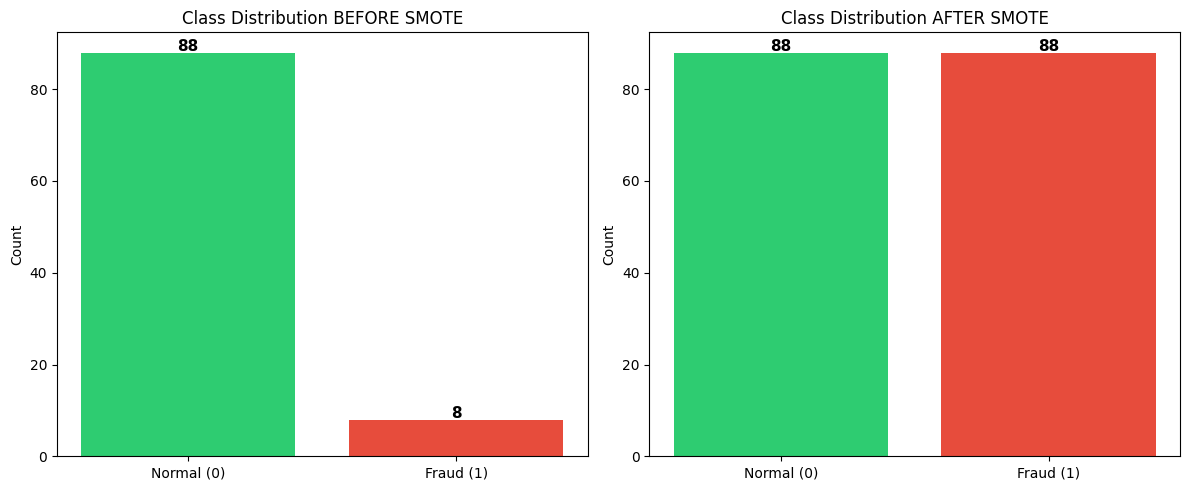

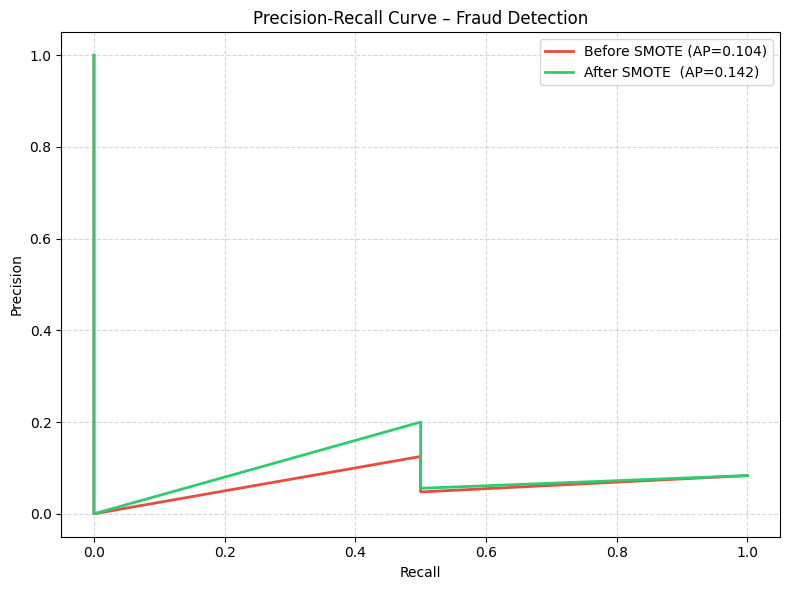

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             precision_recall_curve, average_precision_score)
from imblearn.over_sampling import SMOTE

# 1. Load Dataset
df = pd.read_csv("fraud_smote.csv")
print(df.head())
print("Shape:", df.shape)

X = df[["Amount", "Time", "Feature1", "Feature2"]]
y = df["Fraud"]

# 2. Check Class Imbalance
print("\nClass Distribution BEFORE SMOTE:")
print(Counter(y))

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Model BEFORE SMOTE
rf_before = RandomForestClassifier(n_estimators=50, random_state=42)
rf_before.fit(X_train, y_train)
pred_before = rf_before.predict(X_test)
prob_before = rf_before.predict_proba(X_test)[:, 1]
print("\n--- BEFORE SMOTE ---")
print(classification_report(y_test, pred_before))

# 5. Apply SMOTE
smote   = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
print("\nClass Distribution AFTER SMOTE:")
print(Counter(y_res))

# 6. Model AFTER SMOTE
rf_after = RandomForestClassifier(n_estimators=50, random_state=42)
rf_after.fit(X_res, y_res)
pred_after = rf_after.predict(X_test)
prob_after = rf_after.predict_proba(X_test)[:, 1]
print("\n--- AFTER SMOTE ---")
print(classification_report(y_test, pred_after))

# 7. Visualization 1 – Class Distribution Before & After SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
before_counts = Counter(y_train)
after_counts  = Counter(y_res)

for ax, counts, title in zip(
    axes,
    [before_counts, after_counts],
    ["Class Distribution BEFORE SMOTE", "Class Distribution AFTER SMOTE"]
):
    ax.bar(["Normal (0)", "Fraud (1)"],
           [counts[0], counts[1]],
           color=["#2ecc71", "#e74c3c"])
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Count")
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 0.3, str(v), ha="center",
                fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("s5_class_distribution.png", dpi=150)
plt.show()

# 8. Visualization 2 – Precision-Recall Curve
prec_b, rec_b, _ = precision_recall_curve(y_test, prob_before)
prec_a, rec_a, _ = precision_recall_curve(y_test, prob_after)
ap_b = average_precision_score(y_test, prob_before)
ap_a = average_precision_score(y_test, prob_after)

plt.figure(figsize=(8, 6))
plt.plot(rec_b, prec_b, label=f"Before SMOTE (AP={ap_b:.3f})",
         color="#e74c3c", lw=2)
plt.plot(rec_a, prec_a, label=f"After SMOTE  (AP={ap_a:.3f})",
         color="#2ecc71", lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – Fraud Detection")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("s5_precision_recall.png", dpi=150)
plt.show()